In [2]:
import datetime
import numpy as np

from itertools import islice, cycle
from more_itertools import pairwise

import pandas as pd

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

import seaborn as sns
sns.set(style='whitegrid')
sns.set(rc={'figure.figsize':(17, 9)})

from IPython.core.display import display, HTML, clear_output
display(HTML('<style>.container { width:80% !important; }</style>'))
display(HTML('<style>.prompt { min-width:10ex !important; }</style>'))
display(HTML('<style>div#notebook { font-size:12px !important; }</style>'))

## Этап 1. Первичная подготовка данных <a id="step_1"></a>

### Постановка задачи

Прочитайте файлы с данными и проведите первичную оценку их качества. Необходимо проверить:

* корректность типов идентификаторов;
* наличие пропусков и аномалий в пользовательских и контентных признаках;
* согласованность данных между таблицами.

При необходимости устраните найденные проблемы.

---

### Описание исходных данных

В представленном датасете собраны данные по пользователям и объектам (сериалы/фильмы), а также по их взаимодействиям (просмотр контента пользователем) из онлайн-кинотеатра Kion.

Данные по просмотру контента собраны примерно за 6 месяцев — с **2021-03-13** по **2021-08-22** включительно — и разбавлены случайным шумом.
ID пользователей и контента анонимизированы.

**Статистика по датасету:**

* 840k пользователей
* 16k объектов
* 5.5M взаимодействий

---

### users.csv

В данном файле содержится информация о пользователях:

* `user_id` — ID пользователя

* `age` — возрастная группа пользователя, строка вида `"M_N"`
  *(признак получен моделью)*

  * `18_24` — от 18 до 24 лет включительно
  * `25_34` — от 25 до 34 лет включительно
  * `35_44` — от 35 до 44 лет включительно
  * `45_54` — от 45 до 54 лет включительно
  * `55_64` — от 55 до 64 лет включительно
  * `65_inf` — от 65 и старше

* `sex` — пол пользователя
  *(признак получен моделью)*

  * `М` — мужчина
  * `Ж` — женщина

* `income` — доход пользователя, строка вида `"M_N"`
  *(признак получен моделью)*

  * `income_0_20`
  * `income_20_40`
  * `income_40_60`
  * `income_60_90`
  * `income_90_150`
  * `income_150_inf`

* `kids_flg` — флаг «наличие ребёнка»
  *(признак получен моделью)*

* Для определения значений признаков возраста и дохода использовалась отдельная модель.

---

### items.csv

В данном файле содержится информация об объектах (фильмы/сериалы):

* `item_id` — ID контента
* `content_type` — тип контента (фильм, сериал)
* `title` — название на русском
* `title_orig` — оригинальное название
* `genres` — жанры из источника (онлайн-кинотеатры)
* `countries` — страны производства
* `for_kids` — флаг «контент для детей»
* `age_rating` — возрастной рейтинг
* `studios` — студии
* `directors` — режиссёры
* `actors` — актёры
* `keywords` — ключевые слова
* `description` — описание

---

### interactions.csv

В данном файле содержится информация о взаимодействиях пользователей с контентом:

* `user_id` — ID пользователя
* `item_id` — ID контента
* `last_watch_dt` — дата последнего просмотра
* `total_dur` — суммарная длительность просмотров данного контента (в секундах)
* `content_type` — тип контента (фильм, сериал)


In [3]:
users_df = pd.read_csv('users.csv')
items_df = pd.read_csv('items.csv')
interactions_df = pd.read_csv('interactions.csv', parse_dates=['last_watch_dt'])
submission = pd.read_csv('sample_submission.csv')

## Этап 2. Анализ данных (EDA) <a id="step_2"></a>

### Постановка задачи

Проведём разведочный анализ, чтобы получить представление о:

- распределении активности пользователей;

- наиболее популярном контенте;

- наиболее популярных жанрах;

- контенте без просмотров;

- дополнительных аномалиях (полезно для проекта).

Сохраните данные в файлах

# EDA

## Users

In [4]:
users_df.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [5]:
users_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [6]:
users_df.nunique()

,0
user_id,840197
age,6
income,6
sex,2
kids_flg,2


### Preprocess

#### Age

<Axes: xlabel='age'>

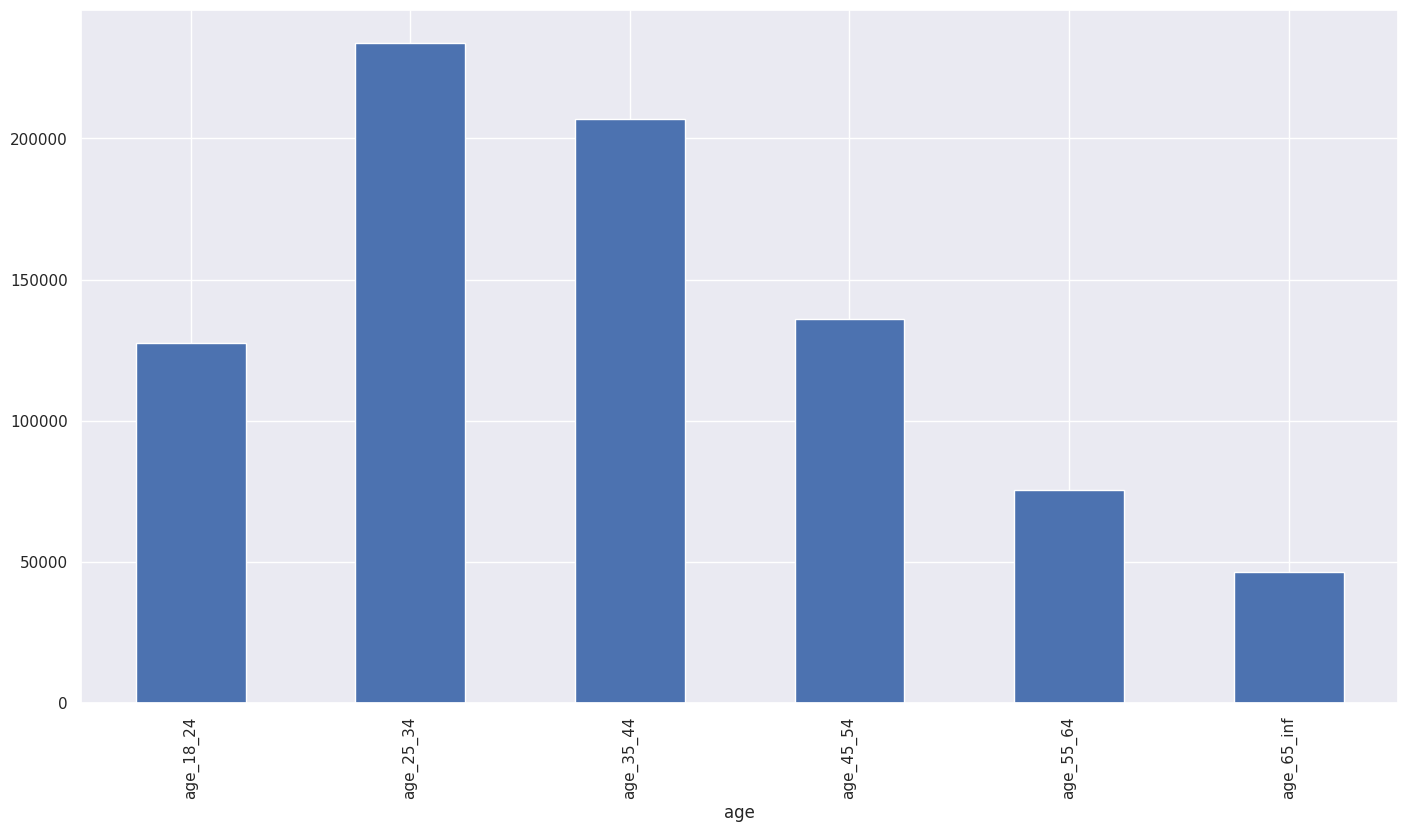

In [7]:
users_df.age.value_counts().sort_index().plot(kind='bar')

In [8]:
users_df['age'] = users_df['age'].fillna('age_unknown')

In [9]:
users_df['age'].value_counts()

,count
age,
age_25_34,233926
age_35_44,207043
age_45_54,135925
age_18_24,127672
age_55_64,75265
age_65_inf,46271
age_unknown,14095


In [10]:
users_df['age'] = users_df['age'].astype('category')

#### Income

In [11]:
users_df.income.value_counts()

,count
income,
income_20_40,471519
income_40_60,248330
income_60_90,68674
income_0_20,21836
income_90_150,13985
income_150_inf,1077


<Axes: xlabel='income'>

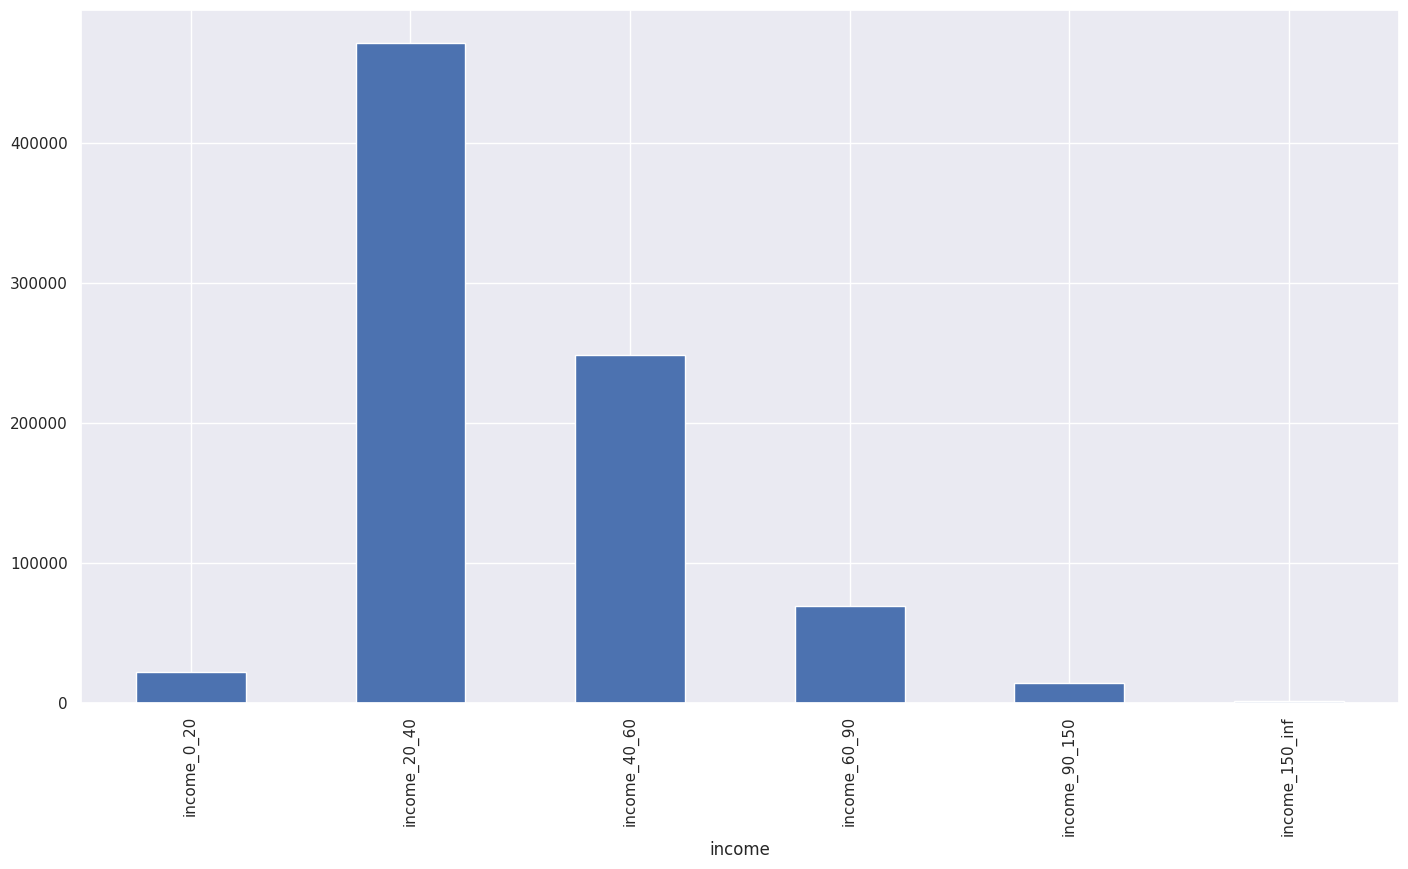

In [12]:
users_df.income.value_counts().iloc[[3,0,1,2,4,5]].plot(kind='bar')

In [13]:
users_df['income'] = users_df['income'].fillna('income_unknown')

In [14]:
users_df['income'].value_counts()

,count
income,
income_20_40,471519
income_40_60,248330
income_60_90,68674
income_0_20,21836
income_unknown,14776
income_90_150,13985
income_150_inf,1077


In [15]:
users_df['income'] = users_df['income'].astype('category')

#### Sex

In [16]:
users_df['sex'].value_counts()

,count
sex,
Ж,425270
М,401096


In [17]:
users_df['sex'] = users_df['sex'].fillna('sex_unknown')

In [18]:
users_df.loc[users_df.sex == 'М', 'sex'] = 'M'
users_df.loc[users_df.sex == 'Ж', 'sex'] = 'F'

In [19]:
users_df['sex'].value_counts()

,count
sex,
F,425270
M,401096
sex_unknown,13831


In [20]:
users_df['sex'] = users_df['sex'].astype('category')

#### kids_flg

In [21]:
users_df['kids_flg'].value_counts()

,count
kids_flg,
0,587209
1,252988


In [22]:
users_df['kids_flg'] = users_df['kids_flg'].astype('bool')

#### Duplicates check

In [23]:
users_df.duplicated(subset=['user_id'], keep=False).sum()

np.int64(0)

### Result

In [24]:
users_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   user_id   840197 non-null  int64   
 1   age       840197 non-null  category
 2   income    840197 non-null  category
 3   sex       840197 non-null  category
 4   kids_flg  840197 non-null  bool    
dtypes: bool(1), category(3), int64(1)
memory usage: 9.6 MB


## Items

In [25]:
items_df.head(1)

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."


In [26]:
items_df.nunique()

,0
item_id,15963
content_type,2
title,15293
title_orig,10575
release_year,105
genres,2771
countries,687
for_kids,2
age_rating,6
studios,38


In [27]:
items_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


### Preprocess

#### content_type

In [28]:
items_df.content_type.value_counts()

,count
content_type,
film,12002
series,3961


In [29]:
items_df['content_type'] = items_df['content_type'].astype('category')

#### title

In [30]:
items_df['title'].head()

,title
0,Поговори с ней
1,Голые перцы
2,Тактическая сила
3,45 лет
4,Все решает мгновение


In [31]:
items_df.duplicated(subset=['title'], keep=False).sum()

np.int64(1266)

In [32]:
items_df['title'] = items_df['title'].str.lower()

#### title_orig

In [33]:
items_df['title_orig'].head()

,title_orig
0,Hable con ella
1,Search Party
2,Tactical Force
3,45 Years
4,NaN


In [34]:
items_df[items_df.title_orig.isna()].countries.value_counts().head()

,count
countries,
Россия,2899
СССР,918
Украина,240
США,101
Великобритания,87


In [35]:
items_df['title_orig'] = items_df['title_orig'].fillna('None')

In [36]:
items_df.duplicated(subset=['title_orig'], keep=False).sum()

np.int64(6007)

In [37]:
items_df.duplicated(subset=['title', 'title_orig'], keep=False).sum()

np.int64(380)

#### release_year

<Axes: >

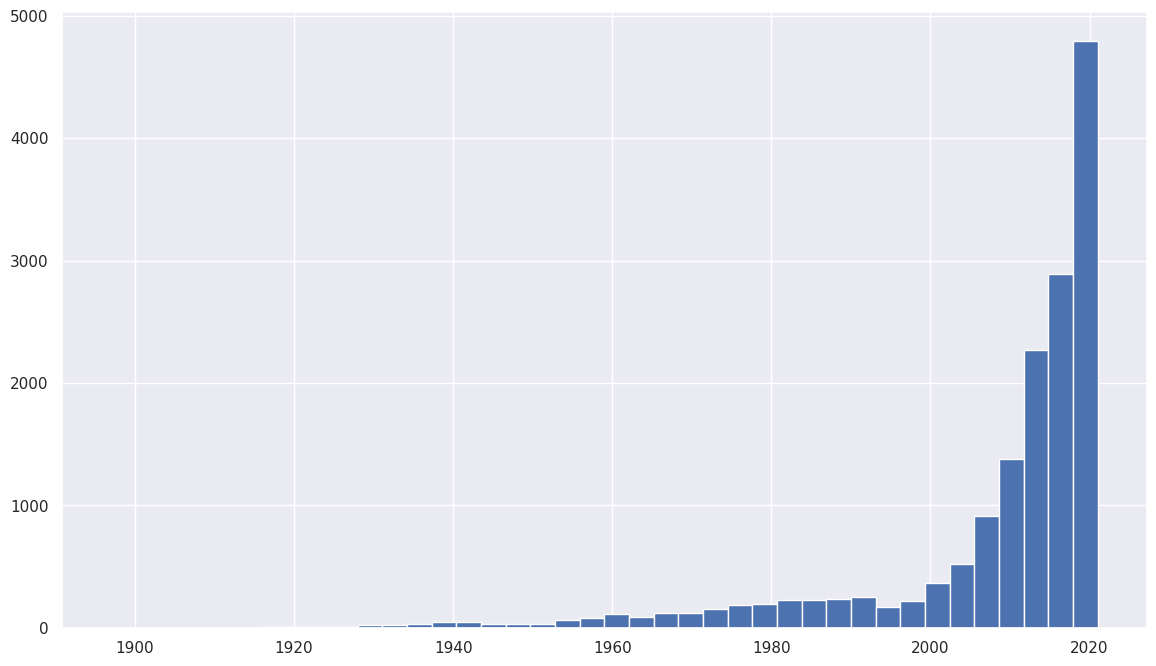

In [38]:
items_df.release_year.hist(figsize=(14, 8), bins=40)

In [39]:
items_df[items_df['release_year'].isna()].head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
89,10950,series,начни дома,None,NaN,фитнес,Россия,NaN,6.0,NaN,NaN,NaN,Приведи себя в хорошую форму дома с минимальны...,"Начни, дома, Россия, спорт-фитнес, спорт-трене..."
294,3901,series,красота лица,None,NaN,фитнес,Россия,NaN,0.0,NaN,NaN,NaN,"Motify научит вас простым, но очень эффективны...","Красота, лица, 2020, Россия, спорт-фитнес, спо..."
374,10656,series,медитации для жизни,None,NaN,фитнес,NaN,NaN,6.0,NaN,NaN,NaN,"В этой программе собраны 3 базовых урока, на к...","Медитации, для, жизни, спорт-фитнес, спорт-тре..."
375,11526,series,психология питания,None,NaN,"фитнес, спорт",NaN,NaN,6.0,NaN,NaN,NaN,В программе от Motify ты узнаешь о психологиче...,"Психология, питания"
572,11532,series,йога старт,None,NaN,фитнес,Россия,NaN,6.0,NaN,NaN,NaN,Программа от Motify подойдет для любого уровня...,"Йога, 2020, Россия, спорт-фитнес, спорт-тренер..."


In [40]:
items_df[items_df['release_year'].isna()][['age_rating', 'genres', 'countries']].value_counts()

age_rating  genres                                                 countries       
6.0         фитнес                                                 Россия              54
0.0         футбол                                                 Россия              22
            фитнес                                                 Россия               5
            зарубежные, детские песни, развитие, для детей         Республика Корея     1
            зарубежные, для детей, западные мультфильмы, развитие  Республика Корея     1
6.0         фитнес                                                 Великобритания       1
Name: count, dtype: int64

Год можно, например, преобразовать к категории следующим способом

In [41]:
items_df.loc[items_df['release_year'].isna(), 'release_year'] = 2020.

In [42]:
items_df.loc[items_df['release_year'] < 1920, 'release_year_cat'] = 'inf_1920'
items_df.loc[items_df['release_year'] >= 2020, 'release_year_cat'] = '2020_inf'

In [43]:
for i in range (1920, 2020, 10):
    items_df.loc[(items_df['release_year'] >= i) & (items_df['release_year'] < i+10), 'release_year_cat'] = f'{i}-{i+10}'

In [44]:
items_df.release_year_cat.value_counts()

,count
release_year_cat,
2010-2020,8788
2020_inf,2276
2000-2010,2168
1980-1990,745
1990-2000,636
1970-1980,553
1960-1970,342
1950-1960,199
1940-1950,117


In [45]:
items_df = items_df.drop(columns=['release_year'])
items_df['release_year_cat'] = items_df['release_year_cat'].astype('category')

#### genres

In [46]:
items_df.genres.value_counts()

,count
genres,
документальное,816
драмы,719
комедии,564
для взрослых,482
"русские, мелодрамы",416
...,...
"драмы, популярное, семейное, приключения",1
"приключения, драмы, зарубежные, военные, фантастика",1
"мюзиклы, советские, комедии",1


In [47]:
items_df['genres'] = items_df['genres'].astype('category')

#### countries

In [48]:
items_df.countries.value_counts()

,count
countries,
Россия,4237
США,4090
СССР,1401
Франция,1158
Великобритания,718
...,...
"Великобритания, Ирландия, Канада, США, Индия",1
"Швеция, Германия, Норвегия, Дания, Исландия, Бельгия, Великобритания",1
"Франция, Великобритания, США",1


In [49]:
items_df[items_df.countries.isna()].shape

(37, 14)

In [50]:
items_df[items_df.countries.isna()].head()

,item_id,content_type,title,title_orig,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,release_year_cat
374,10656,series,медитации для жизни,None,фитнес,NaN,NaN,6.0,NaN,NaN,NaN,"В этой программе собраны 3 базовых урока, на к...","Медитации, для, жизни, спорт-фитнес, спорт-тре...",2020_inf
375,11526,series,психология питания,None,"фитнес, спорт",NaN,NaN,6.0,NaN,NaN,NaN,В программе от Motify ты узнаешь о психологиче...,"Психология, питания",2020_inf
573,63,series,пробуди силу духа,None,"фитнес, спорт",NaN,NaN,6.0,NaN,NaN,NaN,Три коротких и энергичных класса Кундалини йог...,"Пробуди, силу, Духа, 2021, спорт-фитнес, спорт...",2020_inf
750,11551,series,растяжка для кaждого,None,"фитнес, спорт",NaN,NaN,6.0,NaN,NaN,NaN,Программа от Motify поможет вам почувствовать ...,"Растяжка, для, кaждого",2020_inf
1960,16014,series,работа с телом для молодости лица,None,"фитнес, спорт",NaN,NaN,6.0,NaN,NaN,NaN,Программа от Motify направлена на работу с тел...,"Работа, телом, для, молодости, лица",2020_inf


In [51]:
items_df.loc[items_df.countries.isna(), 'countries'] = 'Россия'

In [52]:
items_df['countries'] = items_df['countries'].str.lower()
items_df['countries'] = items_df['countries'].apply(lambda x: ', '.join(sorted(list(set(x.split(', '))))))

In [53]:
items_df.countries.value_counts().head(10)

,count
countries,
россия,4274
сша,4090
ссср,1401
франция,1158
великобритания,718
украина,340
италия,256
канада,233
республика корея,230


In [54]:
items_df['countries'] = items_df['countries'].astype('category')

#### for_kids

In [55]:
items_df['for_kids'].value_counts()

,count
for_kids,
0.0,452
1.0,114


In [56]:
items_df['for_kids'] = items_df['for_kids'].fillna(0)

In [57]:
items_df['for_kids'] = items_df['for_kids'].astype('bool')

#### age_rating

In [58]:
items_df.age_rating.value_counts()

,count
age_rating,
16.0,5729
12.0,4147
18.0,2547
6.0,1538
0.0,1518
21.0,482


In [59]:
items_df[items_df.age_rating.isna()]

,item_id,content_type,title,title_orig,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,release_year_cat
8297,6316,series,машины-помощники,None,"русские, для детей, сериалы, хочу всё знать, р...",россия,False,NaN,NaN,NaN,NaN,Маленькие мальчики всего мира любят играть в м...,"Машины-помощники, 2017, Россия, работа, преодо...",2010-2020
12352,14409,series,бибабу,None,"русские, сериалы, для детей, хочу всё знать, р...",россия,False,NaN,NaN,NaN,NaN,В сказочное подводное царство приглашают мален...,"друзья, магия и волшебство, рыбы, моря и океан...",2010-2020


In [60]:
items_df.loc[items_df.age_rating.isna(), 'age_rating'] = 0

In [61]:
items_df['age_rating'] = items_df['age_rating'].astype('category')

#### studios

In [62]:
items_df['studios'] = items_df['studios'].fillna('Unknown')

In [63]:
items_df['studios'] = items_df['studios'].str.lower()
items_df['studios'] = items_df['studios'].apply(lambda x: ', '.join(sorted(list(set(x.split(', '))))))

In [64]:
items_df['studios'] = items_df['studios'].astype('category')

#### directors

In [65]:
items_df['directors'] = items_df['directors'].fillna('Unknown')

In [66]:
items_df['directors'] = items_df['directors'].str.lower()

In [67]:
items_df['directors'] = items_df['directors'].astype('category')

#### actors

In [68]:
items_df['actors'] = items_df['actors'].fillna('Unknown')

In [69]:
items_df['actors'] = items_df['actors'].astype('category')

#### keywords

In [70]:
items_df['keywords'].head()

,keywords
0,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,"45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [71]:
items_df['keywords'] = items_df['keywords'].fillna('Unknown')

Другой вариант - можно заполнить пропуски копипастой из других фич

In [72]:
items_df['keywords'] = items_df['keywords'].astype('category')

#### description

In [73]:
items_df['description'] = items_df['description'].fillna('-')

#### Duplicates check

In [74]:
items_df.duplicated(subset=['item_id'], keep=False).sum()

np.int64(0)

In [75]:
items_df.duplicated(subset=['title'], keep=False).sum()

np.int64(1300)

In [76]:
items_df[items_df.duplicated(subset=['content_type', 'countries', 'title', 'directors'], keep=False)].sort_values('title')[['content_type', 'title', 'countries', 'for_kids', 'directors']].head()

,content_type,title,countries,for_kids,directors
7333,film,пираты по соседству,нидерланды,False,пим ван хёве
12757,film,пираты по соседству,нидерланды,False,пим ван хёве


In [77]:
items_df.duplicated(subset=['content_type', 'countries', 'title', 'directors'], keep=False).sum()

np.int64(2)

### Result

In [78]:
items_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   item_id           15963 non-null  int64   
 1   content_type      15963 non-null  category
 2   title             15963 non-null  object  
 3   title_orig        15963 non-null  object  
 4   genres            15963 non-null  category
 5   countries         15963 non-null  category
 6   for_kids          15963 non-null  bool    
 7   age_rating        15963 non-null  category
 8   studios           15963 non-null  category
 9   directors         15963 non-null  category
 10  actors            15963 non-null  category
 11  description       15963 non-null  object  
 12  keywords          15963 non-null  category
 13  release_year_cat  15963 non-null  category
dtypes: bool(1), category(9), int64(1), object(3)
memory usage: 2.4+ MB


## Interactions

In [79]:
interactions_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [80]:
interactions_df.shape

(5476251, 5)

In [81]:
interactions_df.nunique()

,0
user_id,962179
item_id,15706
last_watch_dt,163
total_dur,129788
watched_pct,101


In [82]:
print(f'Data date range: {interactions_df.last_watch_dt.min().date()} - {interactions_df.last_watch_dt.max().date()}')

Data date range: 2021-03-13 - 2021-08-22


In [83]:
interactions_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476251 entries, 0 to 5476250
Data columns (total 5 columns):
 #   Column         Dtype         
---  ------         -----         
 0   user_id        int64         
 1   item_id        int64         
 2   last_watch_dt  datetime64[ns]
 3   total_dur      int64         
 4   watched_pct    float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 208.9 MB


### Preprocessing

#### watched_pct

In [84]:
interactions_df.watched_pct.max()

100.0

In [85]:
interactions_df.watched_pct.min()

0.0

In [86]:
interactions_df['watched_pct'] = interactions_df['watched_pct'].astype(pd.Int8Dtype())

In [87]:
interactions_df['watched_pct'] = interactions_df['watched_pct'].fillna(0)

<Axes: >

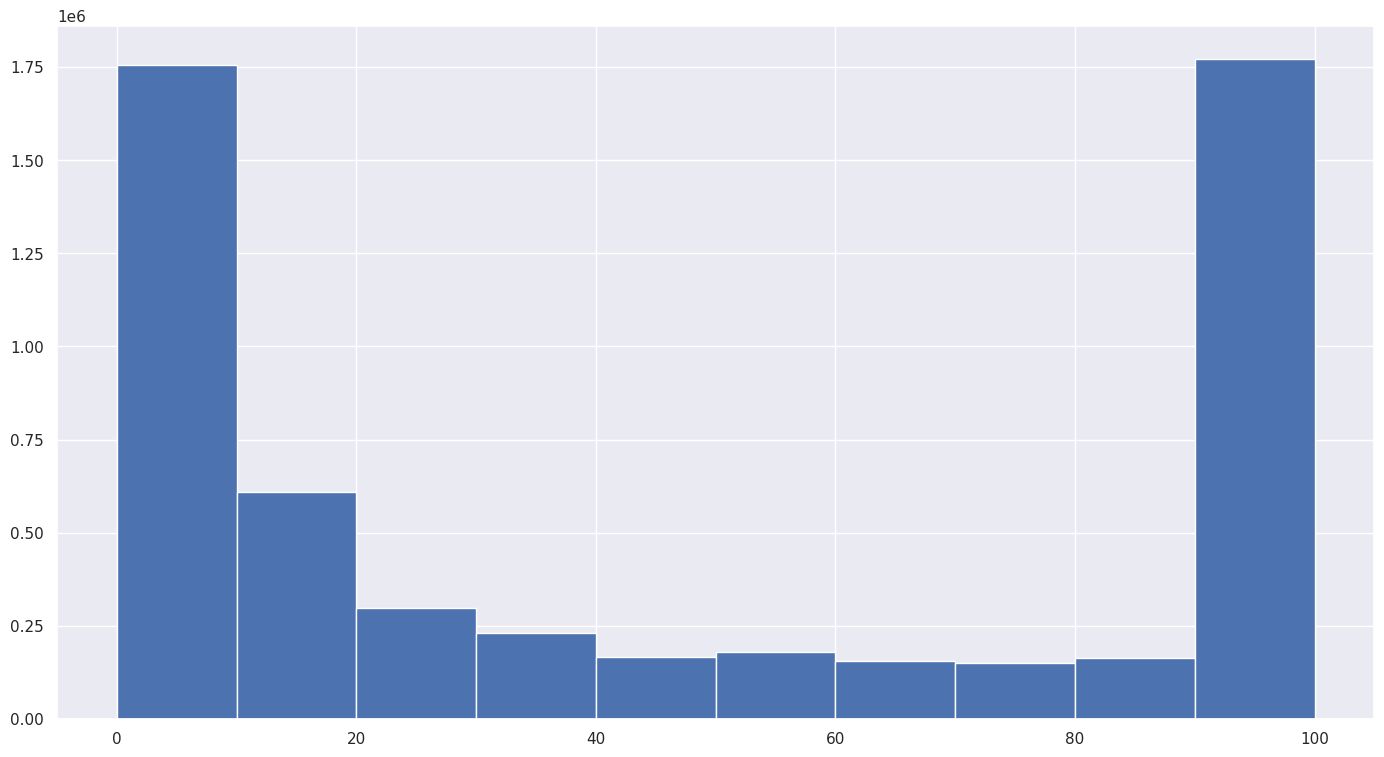

In [88]:
interactions_df['watched_pct'].hist()

#### total_dur

<Axes: >

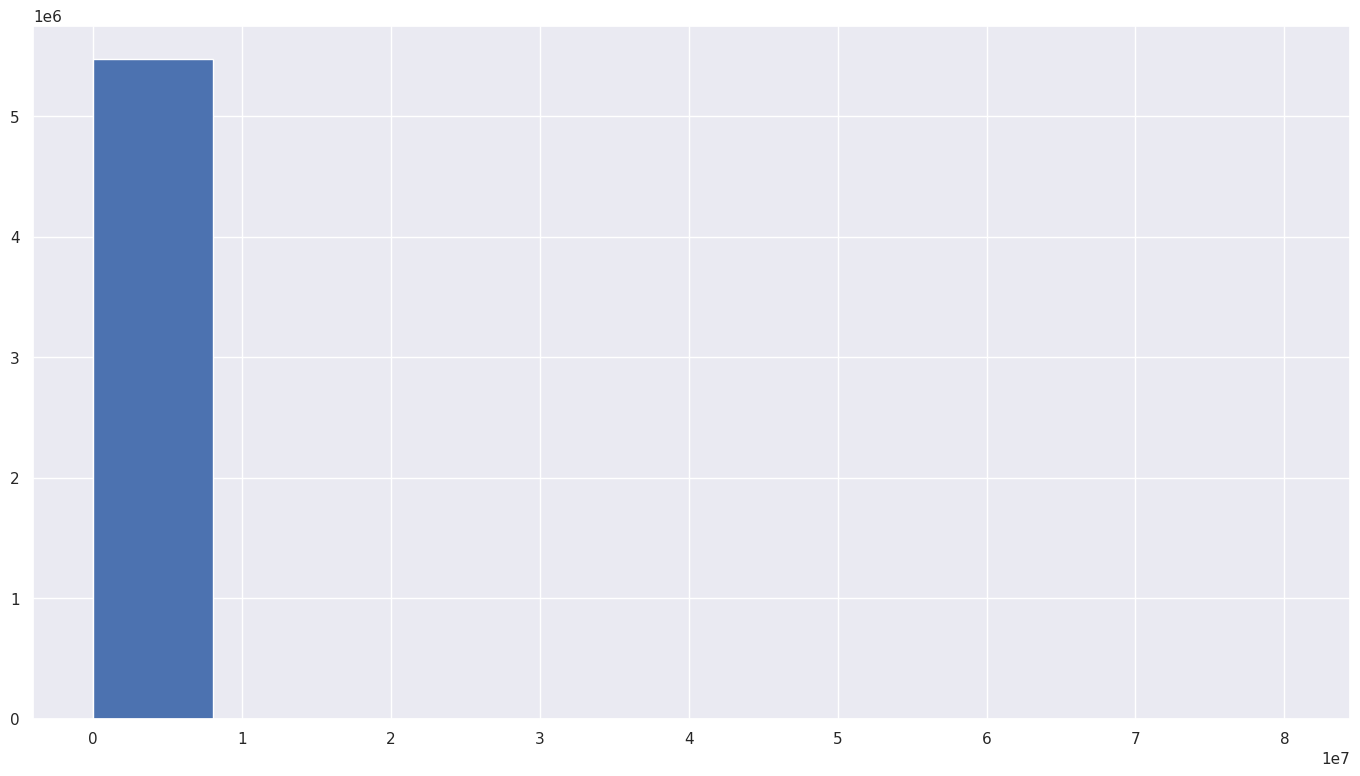

In [89]:
interactions_df['total_dur'].hist()

In [90]:
interactions_df[interactions_df['total_dur'] > 200000].shape

(16042, 5)

<Axes: >

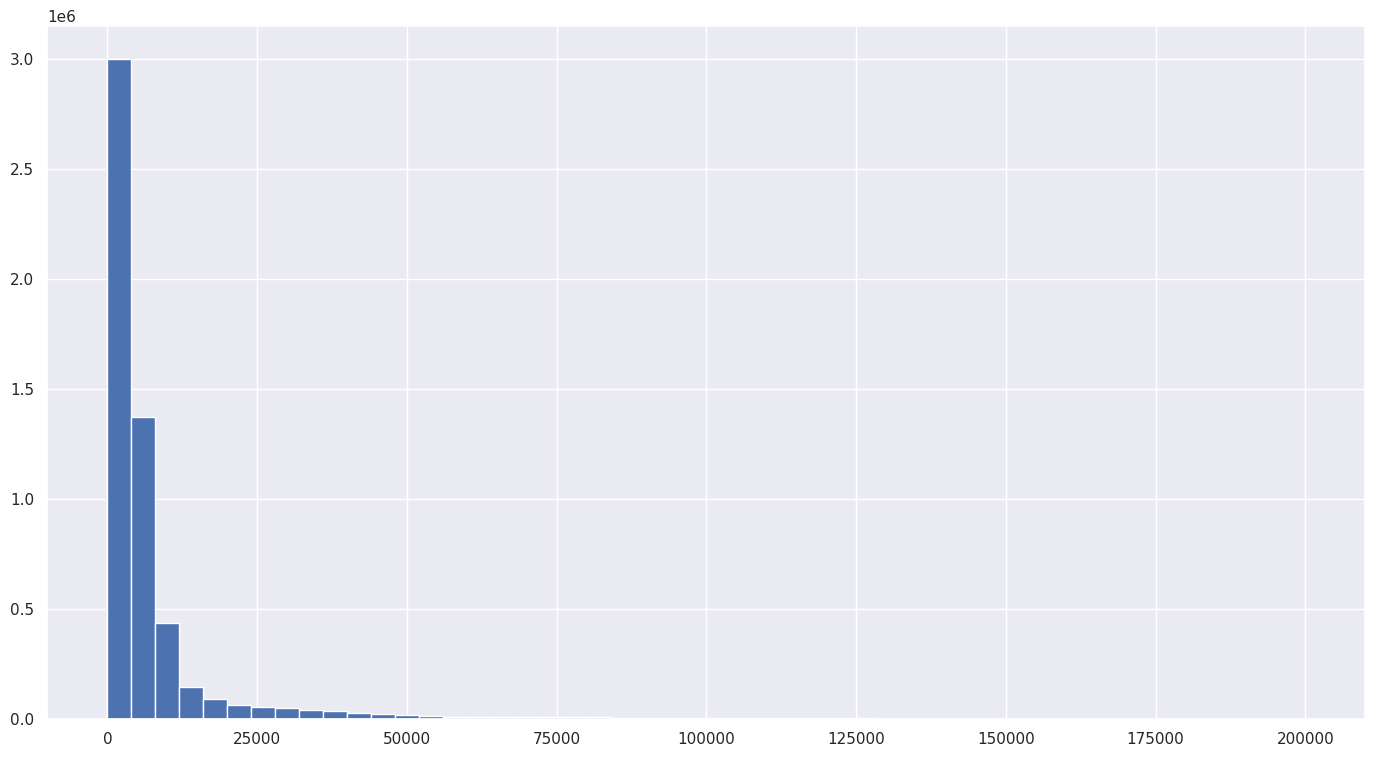

In [91]:
interactions_df[interactions_df['total_dur'] < 200000].total_dur.hist(bins=50)

#### last_watch_dt

In [92]:
interactions_df['last_watch_dt'] = pd.to_datetime(interactions_df['last_watch_dt'])

In [93]:
interactions_df['last_watch_dt'].min()

Timestamp('2021-03-13 00:00:00')

In [94]:
interactions_df['last_watch_dt'].max()

Timestamp('2021-08-22 00:00:00')

<Axes: >

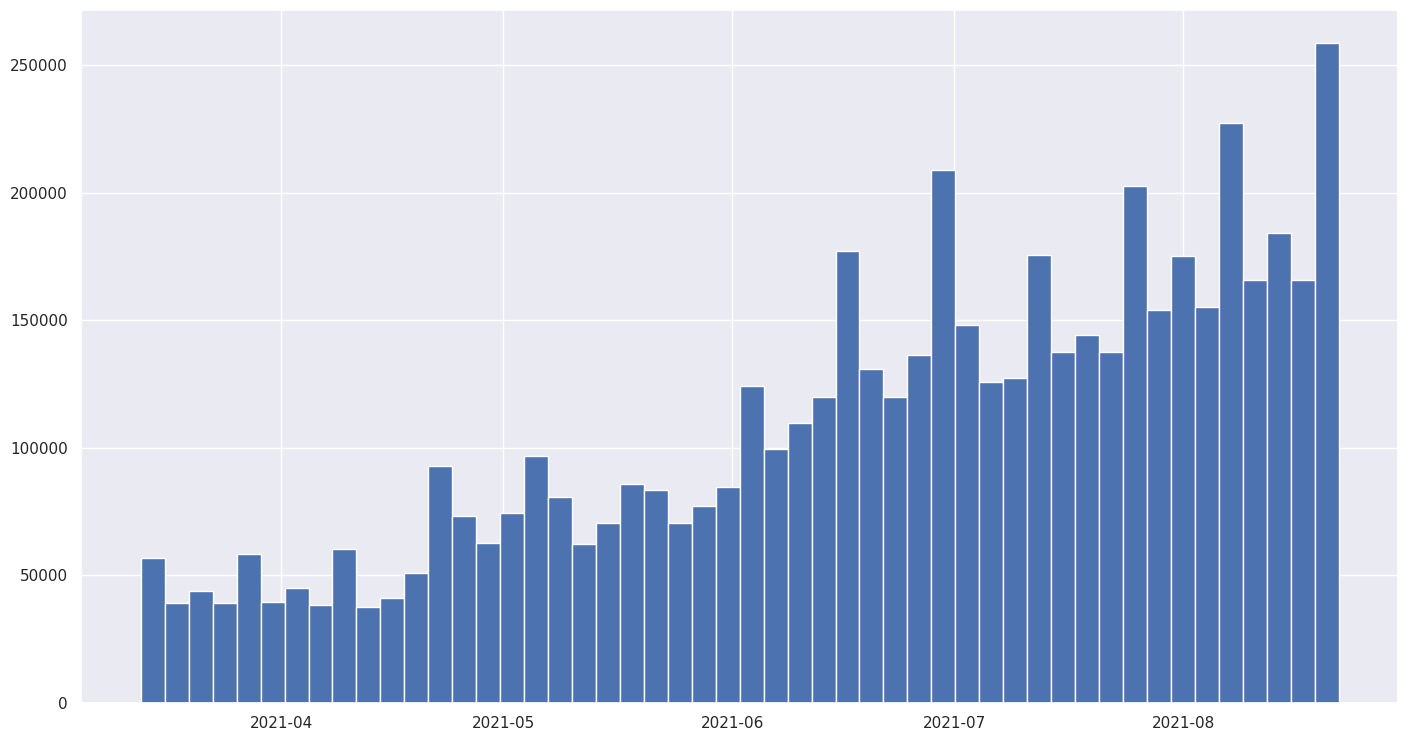

In [95]:
interactions_df['last_watch_dt'].hist(bins=50)

#### Duplicates check

In [96]:
interactions_df.duplicated(subset=['user_id', 'item_id'], keep=False).sum()

np.int64(0)

### Result

In [97]:
interactions_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476251 entries, 0 to 5476250
Data columns (total 5 columns):
 #   Column         Dtype         
---  ------         -----         
 0   user_id        int64         
 1   item_id        int64         
 2   last_watch_dt  datetime64[ns]
 3   total_dur      int64         
 4   watched_pct    Int8          
dtypes: Int8(1), datetime64[ns](1), int64(3)
memory usage: 177.6 MB


# Some stats

In [98]:
interaction_users = interactions_df['user_id'].unique()

common_users = len(np.intersect1d(interaction_users, users_df['user_id']))
users_only_in_interaction = len(np.setdiff1d(interaction_users, users_df['user_id']))
users_only_features = len(np.setdiff1d(users_df['user_id'], interaction_users))
total_users = common_users + users_only_in_interaction + users_only_features

print(f'Кол-во пользователей всего - {total_users}')
print(f'Кол-во пользователей c взаимодействиями и фичами - {common_users} ({common_users / total_users:.2%})')
print(f'Кол-во пользователей только c взаимодействиями - {users_only_in_interaction} ({users_only_in_interaction / total_users:.2%})')
print(f'Кол-во пользователей только c фичами - {users_only_features} ({users_only_features / total_users:.2%})')

Кол-во пользователей всего - 1058088
Кол-во пользователей c взаимодействиями и фичами - 744288 (70.34%)
Кол-во пользователей только c взаимодействиями - 217891 (20.59%)
Кол-во пользователей только c фичами - 95909 (9.06%)


In [99]:
interaction_items = interactions_df['item_id'].unique()

common_items = len(np.intersect1d(interaction_items, items_df['item_id']))
items_only_in_interaction = len(np.setdiff1d(interaction_items, items_df['item_id']))
items_only_features = len(np.setdiff1d(items_df['item_id'], interaction_items))
total_items = common_items + items_only_in_interaction + items_only_features
print(f'Кол-во объектов всего - {total_items}')
print(f'Кол-во объектов c взаимодействиями и фичами - {common_items} ({common_items / total_items:.2%})')
print(f'Кол-во объектов только c взаимодействиями - {items_only_in_interaction} ({items_only_in_interaction / total_items:.2%})')
print(f'Кол-во объектов только c фичами - {items_only_features} ({items_only_features / total_items:.2%})')

Кол-во объектов всего - 15963
Кол-во объектов c взаимодействиями и фичами - 15706 (98.39%)
Кол-во объектов только c взаимодействиями - 0 (0.00%)
Кол-во объектов только c фичами - 257 (1.61%)


График количества пользователей от даты

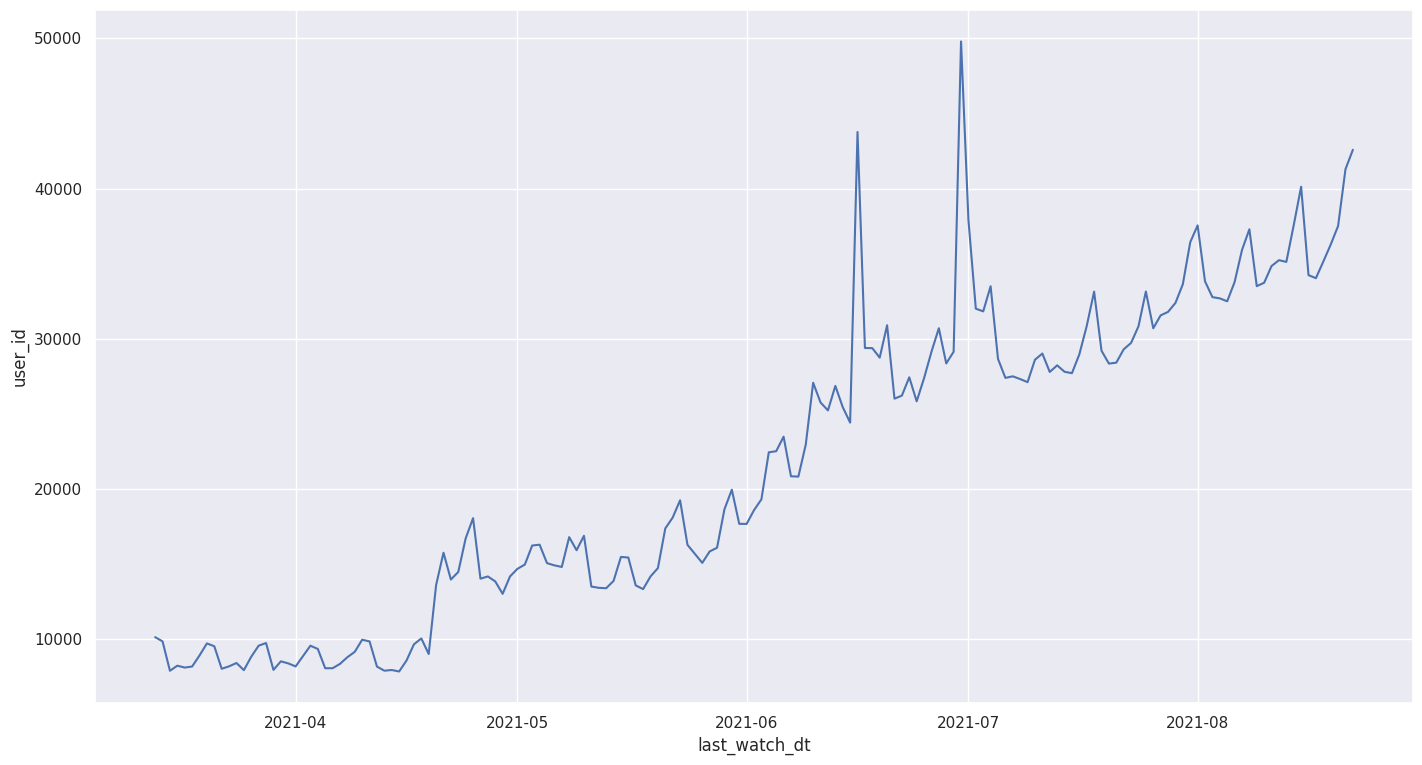

In [100]:
interactions_df_users_count = interactions_df.groupby('last_watch_dt').agg({'user_id': pd.Series.nunique}).reset_index().sort_values('last_watch_dt')
sns.lineplot(data=interactions_df_users_count, x='last_watch_dt', y='user_id');

График количества уникальных пользователей от даты

In [101]:
interactions_df_unique_users_count = []
unique_users = set()

for date in sorted(interactions_df.last_watch_dt.unique()):
    date_unique_users = interactions_df[interactions_df.last_watch_dt == date].user_id.unique()
    interactions_df_unique_users_count.append((date, len(set(date_unique_users) - unique_users)))
    unique_users = unique_users.union(set(date_unique_users))

<Axes: xlabel='date', ylabel='count'>

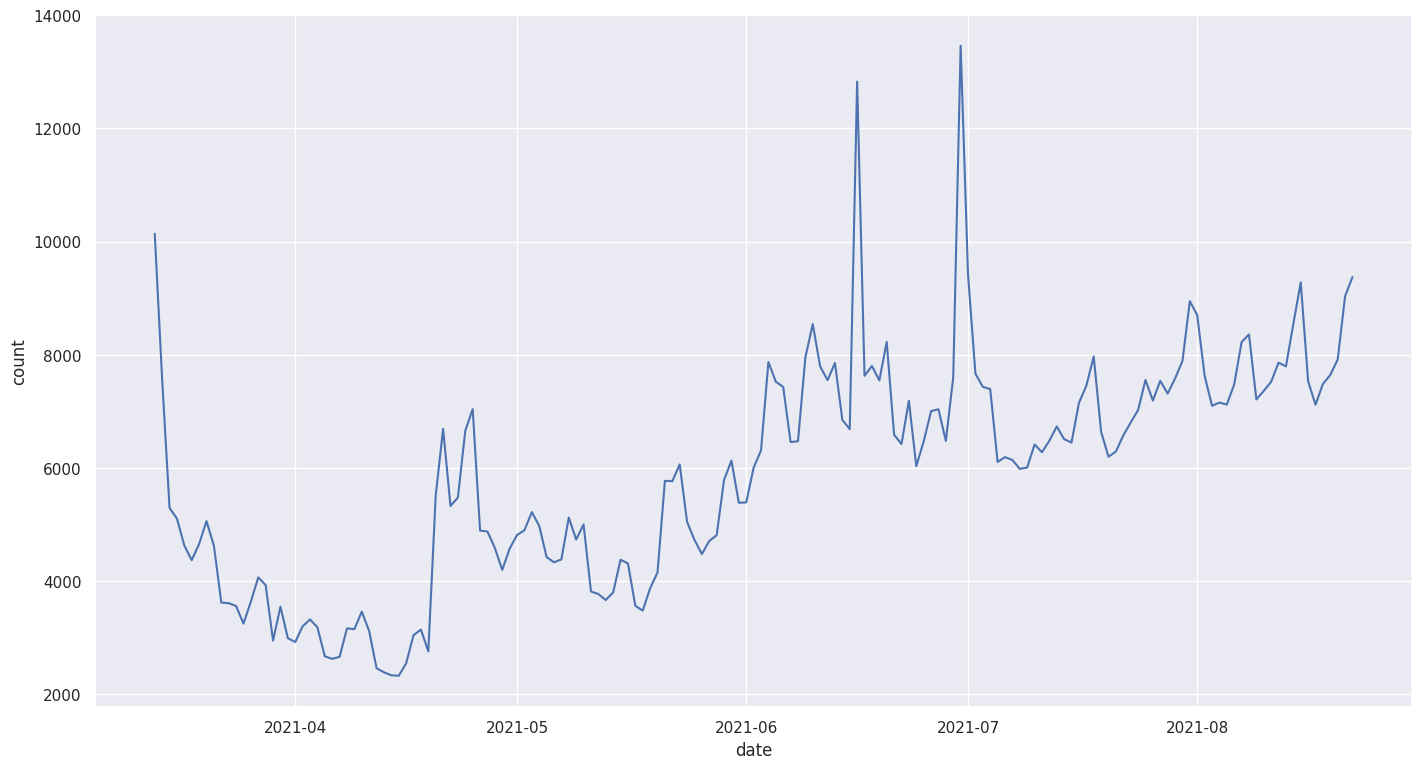

In [102]:
sns.lineplot(data=pd.DataFrame(interactions_df_unique_users_count, columns=['date', 'count']), x='date', y='count')

Ага, очевидно, что каждый день есть у нас есть холодные пользователи. Это необходимо учесть в модели и по хорошему - придумать, что с ними делать

Посмотрим на обьекты

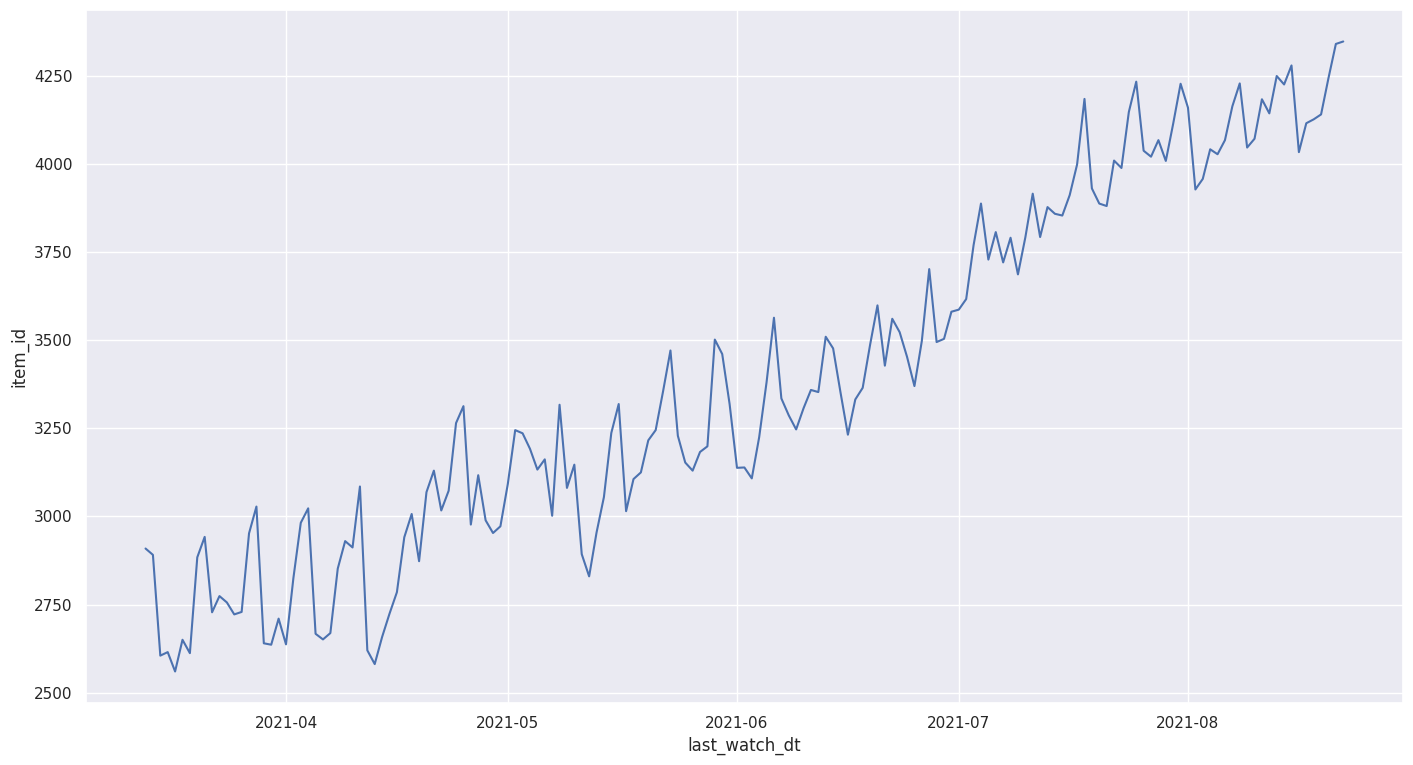

In [103]:
interactions_df_items_count = interactions_df.groupby('last_watch_dt').agg({'item_id': pd.Series.nunique}).reset_index().sort_values('last_watch_dt')
sns.lineplot(data=interactions_df_items_count, x='last_watch_dt', y='item_id');

In [104]:
interactions_df_unique_items_count = []
unique_items = set()

for date in sorted(interactions_df.last_watch_dt.unique()):
    date_unique_items = interactions_df[interactions_df.last_watch_dt == date].item_id.unique()
    interactions_df_unique_items_count.append((date, len(set(date_unique_items) - unique_items)))
    unique_items = unique_items.union(set(date_unique_items))

interactions_df_unique_items_count = pd.DataFrame(interactions_df_unique_items_count, columns=['date', 'count'])

<Axes: xlabel='date', ylabel='count'>

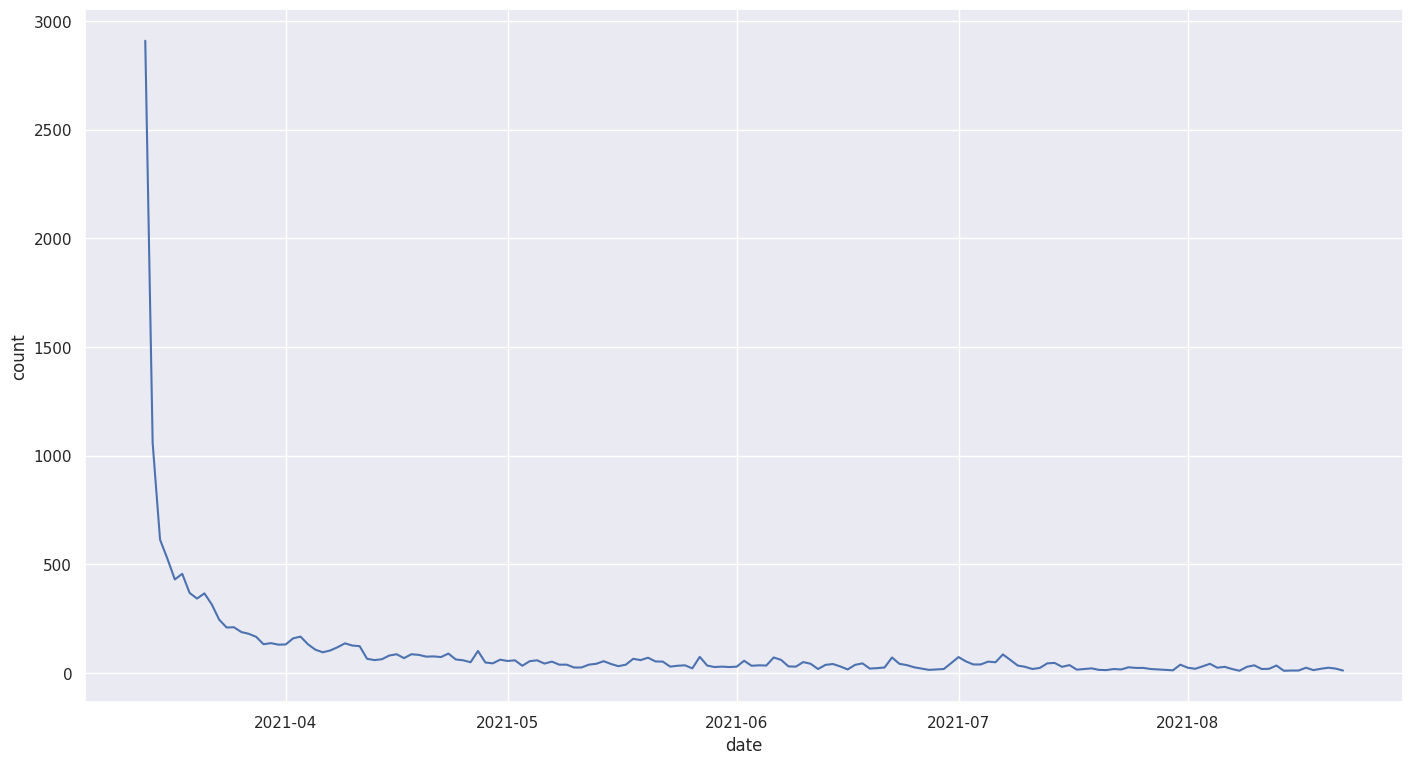

In [105]:
sns.lineplot(data=interactions_df_unique_items_count, x='date', y='count')

<Axes: xlabel='date', ylabel='count'>

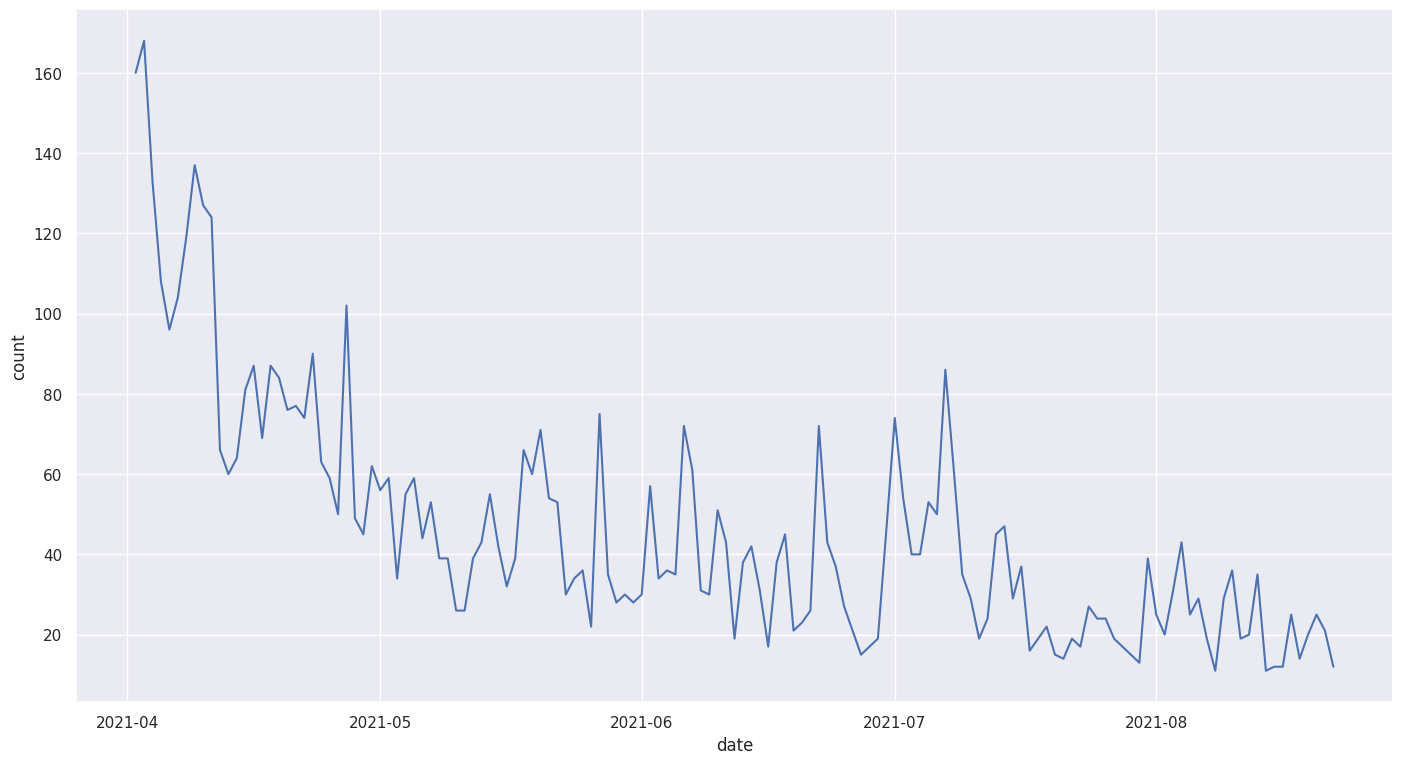

In [106]:
sns.lineplot(data=interactions_df_unique_items_count[interactions_df_unique_items_count.date > '2021-04-01'], x='date', y='count')

Холодные объекты тоже есть, но их явно меньше

Посмотрим на юзеров, для которых нам предсказывать

In [107]:
submission.head()

,user_id,item_id
0,3,"[9728, 15297, 10440, 14488, 13865, 12192, 341,..."
1,11,"[9728, 15297, 10440, 14488, 13865, 12192, 341,..."
2,29,"[9728, 15297, 10440, 14488, 13865, 12192, 341,..."
3,30,"[9728, 15297, 10440, 14488, 13865, 12192, 341,..."
4,33,"[9728, 15297, 10440, 14488, 13865, 12192, 341,..."


In [108]:
interactions_df.user_id.nunique()

962179

In [109]:
submission.user_id.nunique()

193113

In [110]:
len(set(submission.user_id.unique())-set(interactions_df.user_id.unique()))

64943

64943 пользователей из 193113 у нас холодные

Посмотрим сколько взаимодействий по теплым

In [111]:
interactions_of_sub_users = interactions_df[interactions_df.user_id.isin(submission.user_id.unique())]

In [112]:
interactions_of_sub_users.groupby('user_id').agg({'item_id': 'count'}).reset_index().item_id.value_counts().head(10)

,count
item_id,
1,17001
2,12777
3,10473
4,8854
5,7436
6,6471
7,5745
8,4995
9,4426


# Сохранение

In [113]:
users_df.to_csv('users_processed.csv', index=False)
items_df.to_csv('items_processed.csv', index=False)
interactions_df.to_csv('interactions_processed.csv', index=False)

# Согласованность таблиц

In [114]:
print("=== Согласованность таблиц ===")

users_in_interactions = interactions_df['user_id'].nunique()
users_total = users_df['user_id'].nunique()

items_in_interactions = interactions_df['item_id'].nunique()
items_total = items_df['item_id'].nunique()

print(f'Users in interactions: {users_in_interactions}')
print(f'Users total: {users_total}')
print(f'Items in interactions: {items_in_interactions}')
print(f'Items total: {items_total}')

# пользователи из interactions, которых нет в users
missing_users = set(interactions_df['user_id']) - set(users_df['user_id'])
print(f'Missing users in users_df: {len(missing_users)}')

# айтемы из interactions, которых нет в items
missing_items = set(interactions_df['item_id']) - set(items_df['item_id'])
print(f'Missing items in items_df: {len(missing_items)}')

=== Согласованность таблиц ===
Users in interactions: 962179
Users total: 840197
Items in interactions: 15706
Items total: 15963
Missing users in users_df: 217891
Missing items in items_df: 0


# сколько взаимодействий на пользователя

In [115]:
user_activity = interactions_df.groupby('user_id').size()

print(user_activity.describe())

count    962179.000000
mean          5.691510
std          10.886262
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max        1341.000000
dtype: float64


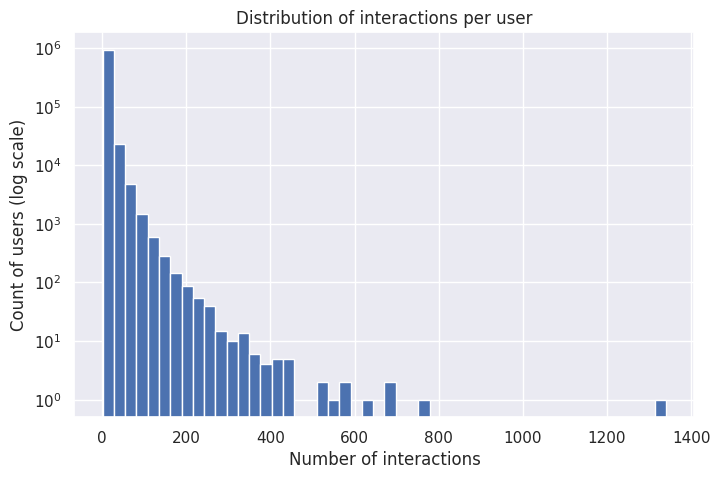

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(user_activity, bins=50)
plt.yscale('log')
plt.title('Distribution of interactions per user')
plt.xlabel('Number of interactions')
plt.ylabel('Count of users (log scale)')
plt.show()

# ТОП-10 самых активных пользователей

In [117]:
user_activity.sort_values(ascending=False).head(10)

,0
user_id,
416206,1341
1010539,764
555233,685
11526,676
409259,625
1057189,579
400913,575
473766,545
230644,529


# Самый популярный контент

In [118]:
item_popularity = interactions_df.groupby('item_id').size().sort_values(ascending=False)

print(item_popularity.describe())
item_popularity.head(10)

count     15706.000000
mean        348.672546
std        3194.053580
min           1.000000
25%           3.000000
50%          12.000000
75%          99.000000
max      202457.000000
dtype: float64


,0
item_id,
10440,202457
15297,193123
9728,132865
13865,122119
4151,91167
3734,74803
2657,68581
4880,55043
142,45367


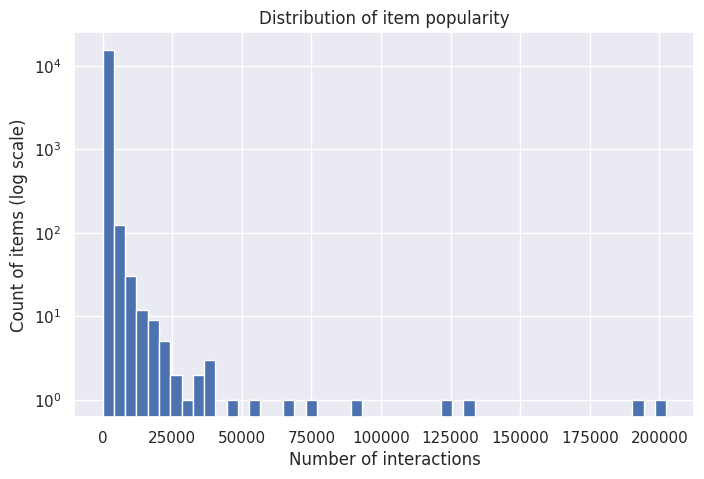

In [119]:
plt.figure(figsize=(8,5))
plt.hist(item_popularity, bins=50)
plt.yscale('log')
plt.title('Distribution of item popularity')
plt.xlabel('Number of interactions')
plt.ylabel('Count of items (log scale)')
plt.show()

# Топ популярных фильмов/сериалов

In [120]:
top_items = (
    interactions_df
    .groupby('item_id')
    .size()
    .reset_index(name='n_interactions')
    .sort_values('n_interactions', ascending=False)
    .head(10)
)

top_items = top_items.merge(
    items_df[['item_id', 'title']],
    on='item_id',
    how='left'
)

top_items

,item_id,n_interactions,title
0,10440,202457,хрустальный
1,15297,193123,клиника счастья
2,9728,132865,гнев человеческий
3,13865,122119,девятаев
4,4151,91167,секреты семейной жизни
5,3734,74803,прабабушка легкого поведения
6,2657,68581,подслушано
7,4880,55043,афера
8,142,45367,маша
9,6809,40372,дуров


# Популярные жанры

In [121]:
items_df['genres_list'] = items_df['genres'].str.split(', ')

items_exploded = items_df.explode('genres_list')
genre_popularity = (
    interactions_df
    .merge(items_exploded[['item_id', 'genres_list']], on='item_id', how='left')
    .groupby('genres_list')
    .size()
    .sort_values(ascending=False)
)

genre_popularity.head(15)

,0
genres_list,
драмы,2304870
комедии,1622884
триллеры,1485733
приключения,1134443
боевики,1095662
мелодрамы,910180
фантастика,716904
детективы,648751
фэнтези,573975


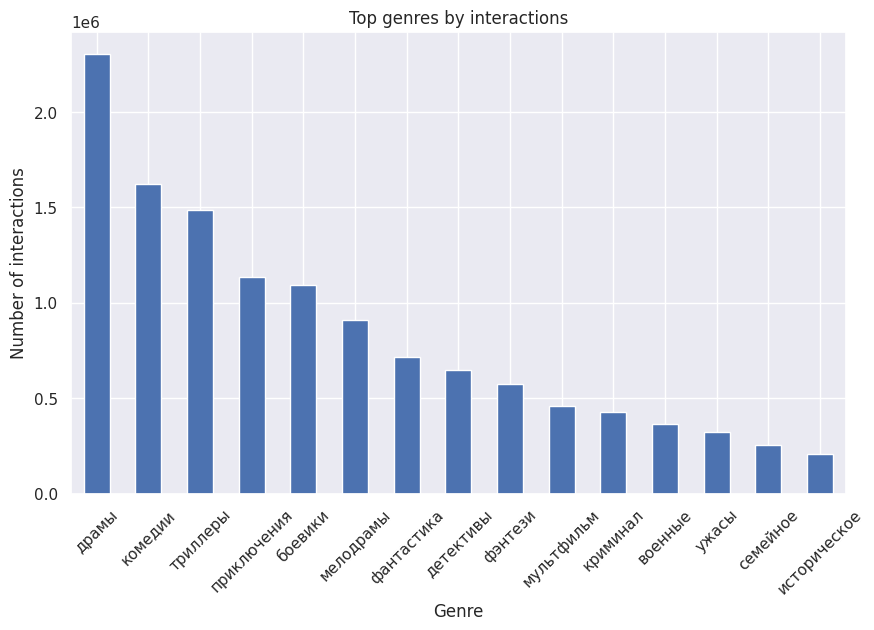

In [122]:
plt.figure(figsize=(10,6))
genre_popularity.head(15).plot(kind='bar')
plt.title('Top genres by interactions')
plt.xlabel('Genre')
plt.ylabel('Number of interactions')
plt.xticks(rotation=45)
plt.show()

# Контент без просмотров (cold items)

In [123]:
items_with_interactions = set(interactions_df['item_id'])
all_items = set(items_df['item_id'])

cold_items = all_items - items_with_interactions

print(f'Items without interactions: {len(cold_items)}')
print(f'Share of cold items: {len(cold_items)/len(all_items):.2%}')

Items without interactions: 257
Share of cold items: 1.61%


In [124]:
items_df[items_df['item_id'].isin(list(cold_items))].head()


,item_id,content_type,title,title_orig,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,release_year_cat,genres_list
5,854,film,северо-юг,None,"драмы, русские",россия,False,16.0,unknown,юрий грубник,"Алексей Воронин, Алексей Мурашов, Алена Алинин...",Авторский фильм молодого режиссера Юрия Грубни...,"Северо-Юг, 2015, Россия, бандиты, гангстеры, б...",2010-2020,"[драмы, русские]"
12,4778,film,три лица,Three Faces,"драмы, зарубежные, артхаус",иран,False,18.0,unknown,джафар панахи,"Бехназ Джафари, Джафар Панахи, Маржие Резаэй, ...",Иранская кинозвезда Бехназ Джафари получает ви...,"Три, лица, 2018, Иран, знаменитости, мечта, ус...",2010-2020,"[драмы, зарубежные, артхаус]"
18,14921,film,баллада о старом оружии,None,"драмы, советские, военные",ссср,False,12.0,unknown,геннадий воронин,"Александр Демьяненко, Борис Чунаев, Валерий Ал...",Кавказская мать отправляется на фронт Великой ...,"Баллада, о, старом, оружии, 1986, СССР, армия,...",1980-1990,"[драмы, советские, военные]"
108,6539,film,как меня зовут,None,"драмы, русские, артхаус",россия,False,16.0,unknown,нигина сайфуллаева,"Александра Бортич, Анна Котова-Дерябина, Игорь...","Один из громких российских фильмов 2014 года, ...","Как, меня, зовут, 2014, Россия, запретная, люб...",2010-2020,"[драмы, русские, артхаус]"
127,2244,film,невеста монстра,Bride of the Monster,"фантастика, зарубежные, ужасы",сша,False,12.0,unknown,эдвард д. вуд мл.,"Бад Осборн, Бела Лугоши, Бен Фроммер, Джон Уор...",Нетленные традиции фантастических фильмов ужас...,"Невеста, монстра, 1955, США, безумные, учёные,...",1950-1960,"[фантастика, зарубежные, ужасы]"


# Cold-start анализ и сохранение подготовленных данных

На этом этапе после базовой обработки и EDA дополнительно анализируется проблема холодного старта.  
Выделяются пользователи с нулевой, короткой и длинной историей взаимодействий, а также cold items — объекты, которые появляются только в тестовой части.

In [ ]:
users_df.to_csv('users_processed.csv', index=False)
items_df.to_csv('items_processed.csv', index=False)
interactions_df.to_csv('interactions_processed.csv', index=False)

In [125]:
required_cols = ["user_id", "item_id", "last_watch_dt"]

for col in required_cols:
    if col not in interactions_df.columns:
        raise ValueError(f"В interactions нет обязательной колонки: {col}")

interactions_df["user_id"] = interactions_df["user_id"].astype(int)
interactions_df["item_id"] = interactions_df["item_id"].astype(int)

if not np.issubdtype(interactions_df["last_watch_dt"].dtype, np.datetime64):
    interactions_df["last_watch_dt"] = pd.to_datetime(interactions_df["last_watch_dt"])

In [128]:
if "watched_pct" not in interactions_df.columns:
    interactions_df["watched_pct"] = 0

if "total_dur" not in interactions_df.columns:
    interactions_df["total_dur"] = 0

interactions_df["watched_pct"] = interactions_df["watched_pct"].fillna(0).astype(float)
interactions_df["total_dur"] = interactions_df["total_dur"].fillna(0).astype(float)

# Если есть дубли user-item, агрегируем их:
# берём последнюю дату, максимальный процент просмотра и максимальную длительность.
interactions = (
    interactions_df
    .sort_values("last_watch_dt")
    .groupby(["user_id", "item_id"], as_index=False)
    .agg({
        "last_watch_dt": "max",
        "watched_pct": "max",
        "total_dur": "max"
    })
)

max_dur = interactions["total_dur"].max()

if max_dur > 0:
    interactions["interaction_score"] = (
        0.7 * interactions["watched_pct"] / 100
        + 0.3 * np.log1p(interactions["total_dur"]) / np.log1p(max_dur)
    )
else:
    interactions["interaction_score"] = interactions["watched_pct"] / 100

interactions["interaction_score"] = interactions["interaction_score"].fillna(0)

display(interactions.head())
print(interactions.shape)

,user_id,item_id,last_watch_dt,watched_pct,total_dur,interaction_score
0,0,6006,2021-07-20,0.0,1.0,0.011424
1,0,7102,2021-07-19,3.0,169.0,0.105644
2,0,9728,2021-07-19,0.0,4.0,0.026525
3,0,12192,2021-07-16,0.0,89.0,0.074162
4,0,14359,2021-07-19,2.0,130.0,0.094349


(5476251, 6)


In [131]:
items_df["item_id"] = items_df["item_id"].astype(int)
users_df["user_id"] = users_df["user_id"].astype(int)

for col in ["age", "income", "sex", "kids_flg"]:
    if col not in users_df.columns:
        users_df[col] = "unknown"
    else:
        users_df[col] = users_df[col].astype("object")

    users_df[col] = users_df[col].where(users_df[col].notna(), "unknown").astype(str)


text_cols = [
    "title",
    "title_orig",
    "genres",
    "countries",
    "studios",
    "directors",
    "actors",
    "description",
    "keywords",
    "content_type"
]

for col in text_cols:
    if col not in items_df.columns:
        items_df[col] = ""
    else:
        items_df[col] = items_df[col].astype("object")

    items_df[col] = items_df[col].where(items_df[col].notna(), "").astype(str)



if "release_year" not in items_df.columns:
    items_df["release_year"] = np.nan

items_df["release_year"] = pd.to_numeric(items_df["release_year"], errors="coerce")

if "age_rating" in items_df.columns:
    items_df["age_rating"] = pd.to_numeric(items_df["age_rating"], errors="coerce")
else:
    items_df["age_rating"] = np.nan

if "for_kids" not in items_df.columns:
    items_df["for_kids"] = "unknown"
else:
    items_df["for_kids"] = items_df["for_kids"].astype("object")

items_df["for_kids"] = items_df["for_kids"].where(items_df["for_kids"].notna(), "unknown").astype(str)


def release_year_category(y):
    if pd.isna(y):
        return "unknown"

    y = int(y)

    if y < 1980:
        return "before_1980"
    elif y < 1990:
        return "1980s"
    elif y < 2000:
        return "1990s"
    elif y < 2010:
        return "2000s"
    elif y < 2020:
        return "2010s"
    else:
        return "2020s"


items_df["release_year_cat"] = items_df["release_year"].apply(release_year_category)

items_df["item_text"] = (
    items_df["title"] + " " +
    items_df["title_orig"] + " " +
    items_df["genres"] + " " +
    items_df["countries"] + " " +
    items_df["studios"] + " " +
    items_df["directors"] + " " +
    items_df["actors"] + " " +
    items_df["description"] + " " +
    items_df["keywords"] + " " +
    items_df["release_year_cat"] + " " +
    items_df["content_type"]
)

display(items_df.head())
display(users_df.head())

,item_id,content_type,title,title_orig,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,release_year_cat,genres_list,release_year,item_text
0,10711,film,поговори с ней,Hable con ella,"драмы, зарубежные, детективы, мелодрамы",испания,False,16.0,unknown,педро альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ...",unknown,"[драмы, зарубежные, детективы, мелодрамы]",NaN,"поговори с ней Hable con ella драмы, зарубежны..."
1,2508,film,голые перцы,Search Party,"зарубежные, приключения, комедии",сша,False,16.0,unknown,скот армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео...",unknown,"[зарубежные, приключения, комедии]",NaN,"голые перцы Search Party зарубежные, приключен..."
2,10716,film,тактическая сила,Tactical Force,"криминал, зарубежные, триллеры, боевики, комедии",канада,False,16.0,unknown,адам п. калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг...",unknown,"[криминал, зарубежные, триллеры, боевики, коме...",NaN,"тактическая сила Tactical Force криминал, зару..."
3,7868,film,45 лет,45 Years,"драмы, зарубежные, мелодрамы",великобритания,False,16.0,unknown,эндрю хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю...",unknown,"[драмы, зарубежные, мелодрамы]",NaN,"45 лет 45 Years драмы, зарубежные, мелодрамы в..."
4,16268,film,все решает мгновение,None,"драмы, спорт, советские, мелодрамы",ссср,False,12.0,ленфильм,виктор садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж...",unknown,"[драмы, спорт, советские, мелодрамы]",NaN,"все решает мгновение None драмы, спорт, советс..."


,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,M,True
1,962099,age_18_24,income_20_40,M,False
2,1047345,age_45_54,income_40_60,F,False
3,721985,age_45_54,income_20_40,F,False
4,704055,age_35_44,income_60_90,F,False


In [132]:
n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
n_interactions = len(interactions)

density = n_interactions / (n_users * n_items)
sparsity = 1 - density

sparsity_stats = pd.DataFrame({
    "metric": [
        "users",
        "items",
        "interactions",
        "density",
        "sparsity",
        "sparsity_percent"
    ],
    "value": [
        n_users,
        n_items,
        n_interactions,
        density,
        sparsity,
        sparsity * 100
    ]
})

display(sparsity_stats)

,metric,value
0,users,9.621790e+05
1,items,1.570600e+04
2,interactions,5.476251e+06
3,density,3.623780e-04
4,sparsity,9.996376e-01
5,sparsity_percent,9.996376e+01


In [133]:
split_date = interactions["last_watch_dt"].quantile(0.8)

train = interactions[interactions["last_watch_dt"] <= split_date].copy()
test = interactions[interactions["last_watch_dt"] > split_date].copy()

split_stats = pd.DataFrame({
    "metric": [
        "split_date",
        "train_interactions",
        "test_interactions",
        "train_users",
        "test_users",
        "train_items",
        "test_items"
    ],
    "value": [
        split_date,
        len(train),
        len(test),
        train["user_id"].nunique(),
        test["user_id"].nunique(),
        train["item_id"].nunique(),
        test["item_id"].nunique()
    ]
})

display(split_stats)

,metric,value
0,split_date,2021-08-04 00:00:00
1,train_interactions,4423600
2,test_interactions,1052651
3,train_users,819309
4,test_users,312327
5,train_items,15331
6,test_items,8863


In [134]:
train_users = set(train["user_id"].unique())
test_users = set(test["user_id"].unique())

full_cold_users = list(test_users - train_users)
known_test_users = list(test_users & train_users)

print("Full cold users:", len(full_cold_users))
print("Known test users:", len(known_test_users))
print("Full cold share in test:", len(full_cold_users) / len(test_users))

Full cold users: 142870
Known test users: 169457
Full cold share in test: 0.4574372372545441


In [135]:
user_hist_len_train = (
    train
    .groupby("user_id")
    .size()
    .reset_index(name="n_interactions")
)

test_user_set = set(test["user_id"].unique())

very_cold_users = user_hist_len_train[
    user_hist_len_train["n_interactions"] <= 2
]["user_id"].tolist()

semi_cold_users = user_hist_len_train[
    (user_hist_len_train["n_interactions"] >= 3) &
    (user_hist_len_train["n_interactions"] <= 5)
]["user_id"].tolist()

medium_users = user_hist_len_train[
    (user_hist_len_train["n_interactions"] >= 6) &
    (user_hist_len_train["n_interactions"] <= 9)
]["user_id"].tolist()

warm_users = user_hist_len_train[
    user_hist_len_train["n_interactions"] >= 10
]["user_id"].tolist()

# Оставляем только тех, кто есть в test
very_cold_users = [u for u in very_cold_users if u in test_user_set]
semi_cold_users = [u for u in semi_cold_users if u in test_user_set]
medium_users = [u for u in medium_users if u in test_user_set]
warm_users = [u for u in warm_users if u in test_user_set]

segments = {
    "full_cold_0": full_cold_users,
    "very_cold_1_2": very_cold_users,
    "semi_cold_3_5": semi_cold_users,
    "medium_6_9": medium_users,
    "warm_10_plus": warm_users,
}

segment_stats = pd.DataFrame({
    "segment": list(segments.keys()),
    "n_users": [len(v) for v in segments.values()]
})

segment_stats["share_of_test_users"] = (
    segment_stats["n_users"] / test["user_id"].nunique()
)

display(segment_stats)

,segment,n_users,share_of_test_users
0,full_cold_0,142870,0.457437
1,very_cold_1_2,46344,0.148383
2,semi_cold_3_5,38243,0.122445
3,medium_6_9,28614,0.091616
4,warm_10_plus,56256,0.180119


In [136]:
train_items = set(train["item_id"].unique())
test_items = set(test["item_id"].unique())

cold_items = list(test_items - train_items)
known_test_items = list(test_items & train_items)

cold_item_stats = pd.DataFrame({
    "metric": [
        "cold_items_in_test",
        "known_test_items",
        "test_items",
        "cold_items_share"
    ],
    "value": [
        len(cold_items),
        len(known_test_items),
        len(test_items),
        len(cold_items) / len(test_items)
    ]
})

display(cold_item_stats)

,metric,value
0,cold_items_in_test,375.000000
1,known_test_items,8488.000000
2,test_items,8863.000000
3,cold_items_share,0.042311


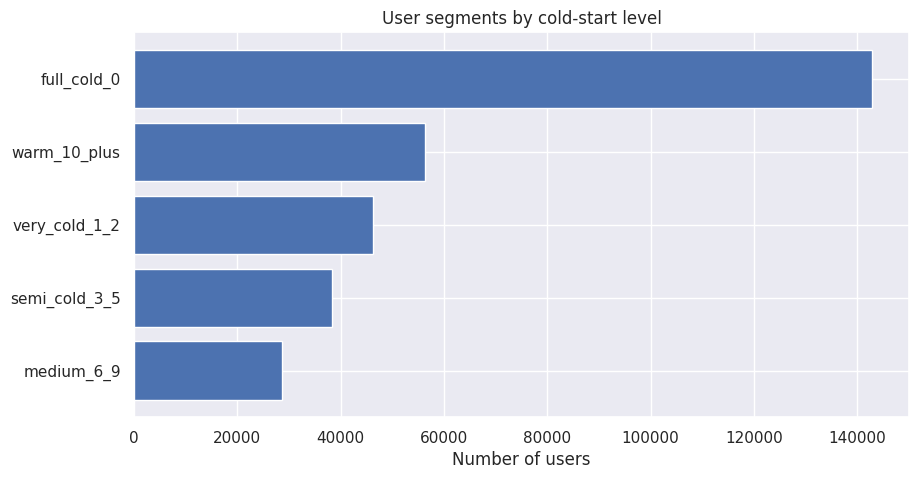

In [137]:
import matplotlib.pyplot as plt

plot_df = segment_stats.sort_values("n_users", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["segment"], plot_df["n_users"])
plt.xlabel("Number of users")
plt.title("User segments by cold-start level")
plt.show()

## Вывод по cold-start анализу

После временного разбиения данных было выявлено, что проблема холодного старта является существенной для рассматриваемого датасета.

В тестовой выборке обнаружено **142 870 full cold users**, то есть пользователей, которые отсутствовали в обучающей выборке, но появились в тестовом периоде. Их доля составляет около **45.7% от всех пользователей test**. Это означает, что почти половина пользователей в тестовом периоде не имеет истории взаимодействий в train, поэтому классические персонализированные методы, основанные только на истории просмотров, для них неприменимы.

Также среди пользователей, присутствующих в train, значительная часть имеет короткую историю:
- **very cold users (1–2 взаимодействия)** — 46 344 пользователя;
- **semi-cold users (3–5 взаимодействий)** — 38 243 пользователя;
- **medium users (6–9 взаимодействий)** — 28 614 пользователей;
- **warm users (10+ взаимодействий)** — 56 256 пользователей.

Таким образом, даже среди известных пользователей много тех, для кого доступно мало информации о предпочтениях. Это подтверждает необходимость отдельно анализировать качество моделей по сегментам пользователей, а не только на общей выборке.

Дополнительно было выявлено **375 cold items** в тестовой выборке, что составляет около **4.2% объектов test**. Для таких объектов отсутствуют взаимодействия в train, поэтому collaborative filtering не может построить для них устойчивые представления. В этом случае становятся важны контентные признаки: описание, жанры, актёры, режиссёры и ключевые слова.

Итоговый вывод: задача холодного старта в данном датасете является не искусственной, а реально выраженной. Поэтому дальнейшее сравнение popularity-based, content-based, collaborative и hybrid моделей является обоснованным.

# Выводы по результатам EDA

## Пользователи

После очистки и подготовки данных в исследовании используется более **960 тыс. пользователей** и более **5.4 млн взаимодействий**.

В исходных данных присутствовали пропуски в пользовательских признаках (`age`, `income`, `sex`), которые были обработаны и выделены в отдельные категории неизвестных значений. Основную часть аудитории составляют пользователи возрастных групп **25–44 года**, что соответствует типичной аудитории онлайн-кинотеатров. Распределение пола близко к сбалансированному, без существенного перекоса в сторону одной из групп. Большинство пользователей не имеют детей (`kids_flg = 0`).

Таким образом, данные пользователей обладают достаточной полнотой и могут использоваться как для построения рекомендательных моделей, так и для формирования дополнительных пользовательских признаков.

---

## Контент (Items)

Каталог содержит более **15 тыс. единиц контента**. В него входят фильмы, сериалы и другой видеоконтент различных жанров и категорий.

Покрытие каталога взаимодействиями пользователей является высоким — подавляющее большинство объектов имеют хотя бы одно взаимодействие. При этом была выявлена группа **cold items** — объектов, отсутствующих в обучающей выборке и появляющихся только в тестовом периоде.

Для таких объектов невозможно использовать классические collaborative filtering подходы, поскольку отсутствует историческая информация о взаимодействиях пользователей с ними. Следовательно, для решения проблемы cold items необходимо использовать контентные признаки объектов: описание, жанры, актёров, режиссёров и другую метаинформацию.

---

## Взаимодействия пользователей с контентом

В датасете содержится более **5.4 млн взаимодействий**, что позволяет строить персонализированные рекомендательные модели.

Распределение активности пользователей имеет выраженный **длинный хвост**: большинство пользователей имеют небольшое число взаимодействий, тогда как существует относительно небольшая группа очень активных пользователей. Аналогичная ситуация наблюдается и для объектов контента: небольшая часть фильмов и сериалов аккумулирует значительную долю просмотров.

Это свидетельствует о наличии **popularity bias**, когда популярные объекты получают существенно больше взаимодействий по сравнению с остальным каталогом. Следовательно, рекомендации популярных объектов могут служить сильным baseline для последующего сравнения моделей.

---

## Разреженность данных

User-item матрица характеризуется крайне высокой разреженностью. Плотность матрицы составляет около **0.036%**, что соответствует разреженности порядка **99.96%**.

Подобный уровень разреженности является типичным для рекомендательных систем, однако существенно усложняет применение collaborative filtering методов, поскольку для большинства пар пользователь–объект отсутствуют наблюдаемые взаимодействия.

Высокая разреженность дополнительно подтверждает необходимость использования контентных признаков и гибридных подходов.

---

## Проблема холодного старта

Анализ временного разбиения данных показал наличие выраженной проблемы холодного старта.

Для исследования были выделены следующие группы пользователей:

* **full cold users** — пользователи, отсутствующие в обучающей выборке;
* **very cold users** — пользователи с 1–2 взаимодействиями;
* **semi-cold users** — пользователи с 3–5 взаимодействиями;
* **medium users** — пользователи с 6–9 взаимодействиями;
* **warm users** — пользователи с 10 и более взаимодействиями.

После разделения данных на train и test было выявлено:

* **142 870 full cold users**;
* доля full cold пользователей составляет около **45.7% пользователей тестовой выборки**;
* значительная часть остальных пользователей также обладает короткой историей взаимодействий.

Кроме того, было обнаружено **375 cold items**, что составляет около **4.2% объектов тестовой выборки**.

Полученные результаты показывают, что проблема холодного старта является одной из ключевых для рассматриваемого датасета и должна учитываться при построении рекомендательной системы.

---

## Общие выводы

Проведённый разведочный анализ данных показал, что датасет обладает всеми характерными особенностями реальных рекомендательных систем:

* высокой разреженностью пользовательско-товарной матрицы;
* выраженным popularity bias;
* наличием пользователей с короткой историей взаимодействий;
* присутствием cold users и cold items.

Использование только collaborative filtering подходов в таких условиях может быть недостаточным. Поэтому дальнейшее исследование будет направлено на сравнение popularity-based, content-based, collaborative и гибридных моделей рекомендаций.

Особое внимание будет уделено решению проблемы холодного старта с использованием контентных признаков объектов и двухстадийных рекомендательных систем, включающих этап генерации кандидатов и последующего ранжирования.